<a href="https://colab.research.google.com/github/omkar-2483/Machine-Learning-Deep-Learning/blob/main/D3-Deep-Learning-with-PyTorch/model-development-using-PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Developing Deep Learning Model (Object Recognition) using Pytorch**

## **Load Data**

**Datasets and Data Loaders**: PyTorch uses datasets to store samples and their corresponding labels, and data loaders to feed this data into the network.

**CIFAR-10 Dataset**: Uses the CIFAR-10 dataset, which consists of 60,000 small color photographs divided into 50,000 training images and 10,000 test images.

**Torchvision Library:** Utilizes the Torchvision library to load, summarize, and display the CIFAR-10 dataset for training and testing.

### Import Libraries and and dataset

In [ ]:
import torch
from torchvision.datasets import CIFAR10
from keras.datasets import cifar10
from matplotlib import pyplot
train_data = CIFAR10(root='./train/', train=True, download=True)

100%|██████████| 170M/170M [00:12<00:00, 14.1MB/s]


Extracting ./train/cifar-10-python.tar.gz to ./train/


### Load dataset

In [ ]:
(trainX, trainy), (testX, testy) = cifar10.load_data()
print("train: X=%s, y=%s" % (trainX.shape, trainy.shape) )
print("test: X=%s, y=%s" % (testX.shape, testy.shape) )

train: X=(50000, 32, 32, 3), y=(50000, 1)
test: X=(10000, 32, 32, 3), y=(10000, 1)


50000 images for training and 10000 images for testing. eacch of 32 * 32 px * 3 channels

### Display Image

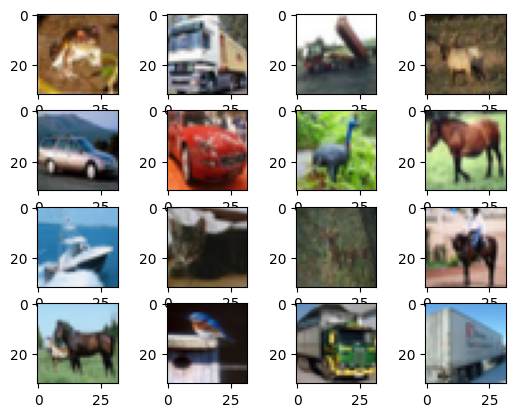

In [ ]:
# plot first 16 images
for i in range(16):
  pyplot.subplot(4,4,i+1)
  pyplot.imshow(trainX[i])
pyplot.show()

### Examine Training Dataset

In [ ]:
print(train_data.data.shape)
print(train_data.class_to_idx)

(50000, 32, 32, 3)
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


### Check class labels

In [ ]:
for i in range(16):
  data, label = train_data[i]
  print("Picture %s photograph: "%(i+1), train_data.classes[label])

Picture 1 photograph:  frog
Picture 2 photograph:  truck
Picture 3 photograph:  truck
Picture 4 photograph:  deer
Picture 5 photograph:  automobile
Picture 6 photograph:  automobile
Picture 7 photograph:  bird
Picture 8 photograph:  horse
Picture 9 photograph:  ship
Picture 10 photograph:  cat
Picture 11 photograph:  deer
Picture 12 photograph:  horse
Picture 13 photograph:  horse
Picture 14 photograph:  bird
Picture 15 photograph:  truck
Picture 16 photograph:  truck


## **Data Transform**
**Transforms in PyTorch:** PyTorch's torchvision library supports common computer vision transformations to adjust and augment data for training or inference.

**Normalization:** Transformations often include resizing images, converting them to tensors, and normalizing them to prevent issues like the exploding gradient problem.

### Import and Trasform for training Data

In [ ]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
train_data_path = './train/'
train_transforms = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std = (0.2023, 0.1994, 0.2010)
    )
])

training_data = CIFAR10(train_data_path, train=True, download=True, transform = train_transforms)

100%|██████████| 170M/170M [00:11<00:00, 14.3MB/s]


Extracting ./train/cifar-10-python.tar.gz to ./train/


### Training Data of first image

In [ ]:
print(training_data[0])

(tensor([[[-1.2854, -1.3629, -1.5180,  ...,  0.4981,  0.4593,  0.4399],
         [-1.4986, -1.5761, -1.7312,  ...,  0.3430,  0.3236,  0.3236],
         [-1.9057, -1.9832, -2.1383,  ...,  0.0522,  0.0522,  0.0716],
         ...,
         [ 1.0408,  1.0021,  0.9439,  ..., -0.3549, -0.5293, -0.6263],
         [ 1.0214,  0.9827,  0.8858,  ...,  0.1297, -0.1223, -0.2386],
         [ 1.0021,  0.9633,  0.8664,  ...,  0.3624,  0.0910, -0.0447]],

        [[-1.1989, -1.2776, -1.4349,  ...,  0.0401,  0.0204,  0.0204],
         [-1.3956, -1.4939, -1.6512,  ..., -0.1566, -0.1566, -0.1566],
         [-1.8086, -1.9069, -2.1036,  ..., -0.5696, -0.5302, -0.5302],
         ...,
         [ 0.3351,  0.2564,  0.1188,  ..., -0.9826, -1.1202, -1.1792],
         [ 0.3941,  0.3154,  0.1778,  ..., -0.4712, -0.6876, -0.8056],
         [ 0.4138,  0.3351,  0.1974,  ..., -0.2156, -0.4712, -0.6089]],

        [[-0.9922, -1.0703, -1.2459,  ..., -0.2313, -0.2118, -0.2118],
         [-1.2069, -1.2849, -1.4605,  ..., -

### Defining transform for testing dataset

In [ ]:
test_data_path = './test/'
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std = (0.2023, 0.1994, 0.2010)
    )
])

test_data = CIFAR10(test_data_path, train=False, download=True, transform = test_transforms)
print(test_data)

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s]


Extracting ./test/cifar-10-python.tar.gz to ./test/
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./test/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
           )


## **Data Batches**

**DataLoader Class:** PyTorch's torch.utils.data.DataLoader class is essential for feeding data into the neural network, supporting both map-style and iterable-style datasets.

**Mini-Batches:** Training with mini-batches (e.g., 64 or 128 samples) is more efficient and requires less memory than using the entire dataset at once.

**Key Parameters:** Important parameters for the DataLoader include batch_size, shuffle, sampler, and num_workers. These parameters help customize data loading, batching, and shuffling to optimize training and testing.

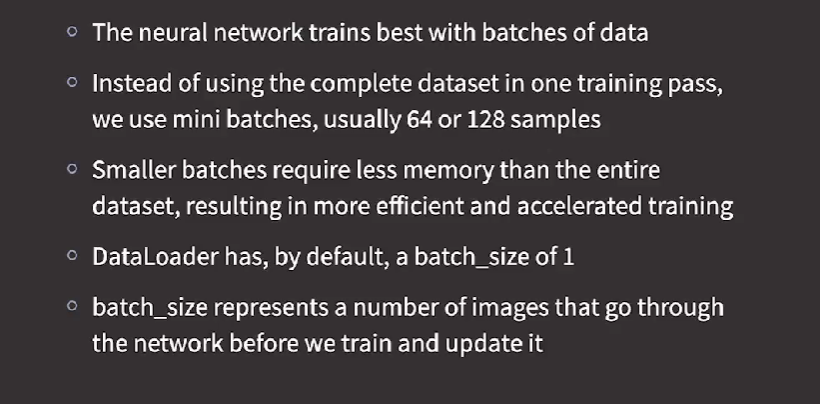

In [24]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

train_data_path = './train/'
test_data_path = './test/'

train_transforms = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std = (0.2023, 0.1994, 0.2010)
    )
])
training_data = CIFAR10(train_data_path, train=True, download=True, transform = train_transforms)

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std = (0.2023, 0.1994, 0.2010)
    )
])
test_data = CIFAR10(test_data_path, train=False, download=True, transform = test_transforms)

batch_size =16
training_data_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


## **Model Development and Training**
**Model Design:** Involves designing one or more model architectures and initializing weights and biases.

**Training Process:** The model is trained by feeding it training data, calculating errors, and adjusting parameters to improve performance.


### Import libraries and dataset

In [22]:
from torchvision import models
from torch import optim
import torch.nn as nn
import torch.nn.functional as F

### Define Neural Network, init and forward function

In [23]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(3,6,5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6,16, 5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16*5*5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

**1. Class Definition (Net)**

* It inherits from nn.Module, which is the base class for all neural networks in PyTorch.
* super(Net, self).__init__() calls the parent class constructor.

**2. Defining Layers (__init__ method)**

Convolutional and Pooling Layers

* self.conv1 = nn.Conv2d(3, 6, 5): First convolutional layer with 3 input channels (for RGB images), 6 output channels, and 5×5 kernel.
* self.pool = nn.MaxPool2d(2, 2): Max pooling layer with 2×2 kernel and stride 2 (reduces spatial size by half).
* self.conv2 = nn.Conv2d(6, 16, 5): Second convolutional layer with 6 input channels, 16 output channels, and a 5×5 kernel

Fully Connected (FC) Layers
* self.fc1 = nn.Linear(16*5*5, 120):  First fully connected layer. 16×5×5 neurons (flattened from the feature map) to 120 neurons.
* self.fc2 = nn.Linear(120, 84): Second fully connected layer with 120 input neurons and 84 output neurons.
* self.fc3 = nn.Linear(84, 10): Final layer with 10 output neurons (for a classification task with 10 classes, e.g., CIFAR-10).

**3. Forward Pass (forward method)**

The forward method defines how the input flows through the network:
* x = self.pool(F.relu(self.conv1(x))): Apply conv1 → ReLU activation → Max pooling.
* x = self.pool(F.relu(self.conv2(x))): Apply conv2 → ReLU activation → Max pooling.
* x = x.view(-1, 16*5*5): Flatten the feature map into a 1D vector (for input to fully connected layers).
* x = F.relu(self.fc1(x)): Fully connected layer fc1 → ReLU activation.
* x = F.relu(self.fc2(x)): Fully connected layer fc2 → ReLU activation.
* x = self.fc3(x): Fully connected layer fc3 (no activation because it's the final output).

### Instantiate the Model

In [27]:
net = Net()
# define the loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum = 0.9)

**Loss Function (criterion)**
* CrossEntropyLoss is used for multi-class classification.
* It combines softmax activation and negative log-likelihood loss.

**Optimizer (optimizer)**
* Stochastic Gradient Descent (SGD) updates model weights during training.
* lr=0.001: Learning rate (step size for updates).
* momentum=0.9: Helps accelerate convergence by considering past gradients.

### Load and Transform Data

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = CIFAR10(root='./data/', train=True, download=True, transform=transform)
trainloader= torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

testset = CIFAR10(root='./data/', train=False, download=True, transform=transform)
testloader= torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:12<00:00, 13.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data/
Files already downloaded and verified


### Train the Network

In [28]:
for epoch in range(10):  #loop over dataset multiple times
   running_loss =0.0
   for i, data in enumerate(trainloader, 0):
    # get the inputs: data in tuple of [inputs, labels]
    inputs, labels = data

    # zero the parameter gradient
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # print statistics
    running_loss+=loss.item()
    if i % 2000==1999: # print every 2000 mini batches
      print(f'epoch [{epoch+1}, batch {i + 1:5d}]  loss: {running_loss / 2000: .3f}')
      running_loss=0.0

print("Training Finished.....")

epoch [1, batch  2000]  loss:  2.226
epoch [1, batch  4000]  loss:  1.883
epoch [1, batch  6000]  loss:  1.679
epoch [1, batch  8000]  loss:  1.586
epoch [1, batch 10000]  loss:  1.510
epoch [1, batch 12000]  loss:  1.466
epoch [2, batch  2000]  loss:  1.375
epoch [2, batch  4000]  loss:  1.364
epoch [2, batch  6000]  loss:  1.312
epoch [2, batch  8000]  loss:  1.306
epoch [2, batch 10000]  loss:  1.298
epoch [2, batch 12000]  loss:  1.269
epoch [3, batch  2000]  loss:  1.201
epoch [3, batch  4000]  loss:  1.209
epoch [3, batch  6000]  loss:  1.188
epoch [3, batch  8000]  loss:  1.182
epoch [3, batch 10000]  loss:  1.177
epoch [3, batch 12000]  loss:  1.154
epoch [4, batch  2000]  loss:  1.098
epoch [4, batch  4000]  loss:  1.098
epoch [4, batch  6000]  loss:  1.107
epoch [4, batch  8000]  loss:  1.117
epoch [4, batch 10000]  loss:  1.104
epoch [4, batch 12000]  loss:  1.084
epoch [5, batch  2000]  loss:  1.014
epoch [5, batch  4000]  loss:  1.027
epoch [5, batch  6000]  loss:  1.023
e

## **Validation and testing**
**Validation and Testing**: After training, the model's performance is validated against data not used in training, and testing is done to evaluate the final model.

### import libraries

In [29]:
from torch.utils.data import random_split

### define neural network, init and forward function
already done

### Instantiate Model and define loss function and optimizer


In [30]:
net = Net()
# define the loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum = 0.9)

### Load and Transform Data

In [33]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = (0.4914, 0.4822, 0.4465),
        std = (0.2023, 0.1994, 0.2018)
    )
])

train_data = CIFAR10(root='./train/', train=True, download=True, transform=train_transforms)
train_set, val_set = random_split(train_data, [40000, 10000])
trainloader= torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
valloader= torch.utils.data.DataLoader(val_set, batch_size=16, shuffle=True)
trainloader= torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=False, num_workers=2)

testset = CIFAR10(root='./data/', train=False, download=True, transform=transform)
testloader= torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


### Set the model to training mode and validation mode for validation

In [ ]:
for epoch in range(10):
   net.train()  # set mode to training
   running_loss =0.0
   for i, data in enumerate(trainloader, 0):
      inputs, labels = data
      optimizer.zero_grad()
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss+=loss.item()

   net.eval()  # set mode to validation
   validation_loss=0.0
   correct=0
   total=0
   with torch.no_grad():
    for data in testloader:
      images, labels=data
      output=net(images)
      loss = criterion(outputs, labels)
      validation_loss+=loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total+=labels.size(0)
      correct+=(predicted==labels).sum().item()
    print(f'Epoch {epoch+1} training_loss: {running_loss / len(trainloader)}, validation_loss: {validation_loss/len(valloader)}, validation_accuracy: {100 * correct / total}%')
print("Training Finished.....")